# Conditional Neural Processes (CNP) for 1D regression.
[Conditional Neural Processes](https://arxiv.org/pdf/1807.01613.pdf) (CNPs) were
introduced as a continuation of
[Generative Query Networks](https://deepmind.com/blog/neural-scene-representation-and-rendering/)
(GQN) to extend its training regime to tasks beyond scene rendering, e.g. to
regression and classification.

In [3]:
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
import datetime
import numpy as np
import plotting_utils_cnp as plotting
import data_generator as data
from matplotlib.backends.backend_pdf import PdfPages
import pandas as pd
import dask.dataframe as dd
import sys
import yaml
import import_ipynb
import conditional_neural_process_model as cnp

In [6]:
import os
from dotenv import load_dotenv
# Load environment variables from .env file
load_dotenv()
resum_path = os.getenv("RESUM_PATH")
resum_lf_tier3_path = os.getenv("RESUM_LF_SIMULATION_TIER3_PATH")
if resum_path is None:
    raise ValueError("Environment variable RESUM_PATH is not set. Make sure to define it in your .env file.")
utilities_path = os.path.join(resum_path, "utilities")
sys.path.append(utilities_path)
import utilities as utils

In [7]:
with open("settings.yaml", "r") as f:
    config = yaml.safe_load(f)

TRAINING_ITERATIONS = int(config["cnp_settings"]["training_iterations"]) # Total number of training points: training_iterations * batch_size * max_content_points
MAX_CONTEXT_POINTS = config["cnp_settings"]["max_context_points"]
MAX_TARGET_POINTS =  config["cnp_settings"]["max_target_points"]
CONTEXT_IS_SUBSET = config["cnp_settings"]["context_is_subset"]
BATCH_SIZE = config["cnp_settings"]["batch_size"]
CONFIG_WISE = config["cnp_settings"]["config_wise"]
PLOT_AFTER = int(config["cnp_settings"]["plot_after"])
torch.manual_seed(0)

names_x=config["simulation_settings"]["design_parameters"]
names_x.extend(config["simulation_settings"]["event_specific_parameters"])
x_size = len(names_x)
name_y =config["simulation_settings"]["y_raw_cnp"]

x_size = len(names_x)
if isinstance(name_y,str):
    y_size = 1
else:
    y_size = len(name_y)

RATIO_TESTING_VS_TRAINING = config["cnp_settings"]["ratio_testing_vs_training"]
version_cnp= config["cnp_settings"]["version"]
version_lf= config["simulation_settings"]["version_lf"]
version_hf= config["simulation_settings"]["version_hf"]

path_to_files=f"{resum_lf_tier3_path}"
path_out = f'{resum_path}/conditional_neutral_process/out/'
f_out = f'{path_out}CNPGauss_{version_cnp}_{TRAINING_ITERATIONS}_c{MAX_CONTEXT_POINTS}_t{MAX_TARGET_POINTS}'

In [8]:
# Set data augmentation parameters
USE_DATA_AUGMENTATION = config["cnp_settings"]["use_data_augmentation"]
USE_BETA = config["cnp_settings"]["use_beta"]
SIGNAL_TO_BACKGROUND_RATIO = config["cnp_settings"]["signal_to_background_ratio"]

if USE_DATA_AUGMENTATION:
    path_out = f'{resum_path}/out/{USE_DATA_AUGMENTATION}/'
    f_out = f'CNPGauss_{version_cnp}_{TRAINING_ITERATIONS}_c{MAX_CONTEXT_POINTS}_t{MAX_TARGET_POINTS}_{USE_DATA_AUGMENTATION}{SIGNAL_TO_BACKGROUND_RATIO}'
    if USE_DATA_AUGMENTATION == "mixup":
        path_to_files = f"{resum_path}/simulation/out/LF/{version_lf}/tier4/beta_{USE_BETA[0]}_{USE_BETA[1]}/"
        f_out = f'CNPGauss_{version_cnp}_{TRAINING_ITERATIONS}_c{MAX_CONTEXT_POINTS}_t{MAX_TARGET_POINTS}_beta_{USE_BETA[0]}_{USE_BETA[1]}'
    elif USE_DATA_AUGMENTATION == "smote" and CONFIG_WISE == True:
        path_to_files = f"{resum_path}/simulation/out/LF/{version_lf}/tier4/smote{SIGNAL_TO_BACKGROUND_RATIO}/"



In [9]:
d_x, d_in, representation_size, d_out = x_size , x_size+y_size, 32, y_size+1
encoder_sizes = [d_in, 32, 64, 128, 128, 128, 64, 48, representation_size]
decoder_sizes = [representation_size + d_x, 32, 64, 128, 128, 128, 64, 48, d_out]

model = cnp.DeterministicModel(encoder_sizes,decoder_sizes)
model.load_state_dict(torch.load(f'{resum_path}/out/{f_out}_model.pth'))
model.eval()


AttributeError: module 'conditional_neural_process_model' has no attribute 'DeterministicModel'

0/303 2024-09-28 23:17:29, LF, radius: 208.7 cm, test loss: 35.67254638671875 (bce 0.17614439129829407)
1/303 2024-09-28 23:17:34, LF, radius: 194.6 cm, test loss: 44.08773422241211 (bce 0.23772013187408447)
2/303 2024-09-28 23:17:41, LF, radius: 240.3 cm, test loss: 79.46257019042969 (bce 0.39267000555992126)
3/303 2024-09-28 23:17:43, LF, radius: 215.3 cm, test loss: 848.0833740234375 (bce 1.3737208843231201)
4/303 2024-09-28 23:17:46, LF, radius: 253.8 cm, test loss: 41.28758239746094 (bce 0.265773743391037)
5/303 2024-09-28 23:17:50, LF, radius: 187.0 cm, test loss: 43.559391021728516 (bce 0.20102070271968842)
6/303 2024-09-28 23:17:53, LF, radius: 194.6 cm, test loss: 40.58503723144531 (bce 0.2203528732061386)
7/303 2024-09-28 23:17:55, LF, radius: 114.8 cm, test loss: 54.597835540771484 (bce 0.232638880610466)
8/303 2024-09-28 23:17:58, LF, radius: 161.6 cm, test loss: 195.4305419921875 (bce 0.6394966840744019)
9/303 2024-09-28 23:18:01, LF, radius: 174.8 cm, test loss: 100.34611

<Figure size 900x300 with 0 Axes>

<Figure size 900x300 with 0 Axes>

<Figure size 900x300 with 0 Axes>

<Figure size 900x300 with 0 Axes>

...

<Figure size 900x300 with 0 Axes>

<Figure size 900x300 with 0 Axes>

<Figure size 900x300 with 0 Axes>

<Figure size 900x300 with 0 Axes>

<Figure size 900x300 with 0 Axes>

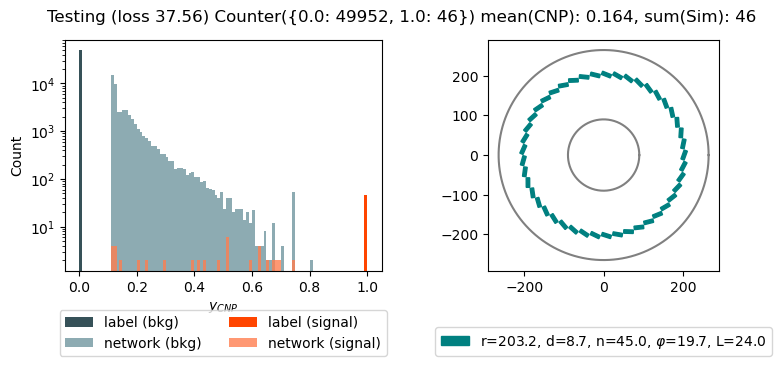

16/303 2024-09-28 23:18:21, LF, radius: 155.8 cm, test loss: 45.901527404785156 (bce 0.20286154747009277)
17/303 2024-09-28 23:18:24, LF, radius: 121.2 cm, test loss: 140.86376953125 (bce 0.5268437266349792)
18/303 2024-09-28 23:18:26, LF, radius: 96.4 cm, test loss: 63.637569427490234 (bce 0.2662884593009949)
19/303 2024-09-28 23:18:28, LF, radius: 168.4 cm, test loss: 40.39055252075195 (bce 0.18017041683197021)
20/303 2024-09-28 23:18:30, LF, radius: 244.4 cm, test loss: 42.27527618408203 (bce 0.24563561379909515)
21/303 2024-09-28 23:18:34, LF, radius: 202.2 cm, test loss: 141.43565368652344 (bce 0.5355429649353027)
22/303 2024-09-28 23:18:37, LF, radius: 172.1 cm, test loss: 42.33588409423828 (bce 0.19202373921871185)
23/303 2024-09-28 23:18:40, LF, radius: 187.3 cm, test loss: 50.84701919555664 (bce 0.2509445548057556)
24/303 2024-09-28 23:18:43, LF, radius: 212.8 cm, test loss: 47.351375579833984 (bce 0.24293659627437592)
25/303 2024-09-28 23:18:46, LF, radius: 208.1 cm, test los

/Users/aschuetz/Documents/Analysis/legend/ML/legend-multi-fidelity-surrogate-model/conditional-neural-process/plotting_utils_cnp.py:166: RuntimeWarning: More than 20 figures have been opened. Figures created through the pyplot interface (`matplotlib.pyplot.figure`) are retained until explicitly closed and may consume too much memory. (To control this warning, see the rcParam `figure.max_open_warning`). Consider using `matplotlib.pyplot.close()`.
  fig, ax = plt.subplots(1, 2, figsize=(9, 3))


36/303 2024-09-28 23:19:13, LF, radius: 161.4 cm, test loss: 78.0011978149414 (bce 0.3638943135738373)
37/303 2024-09-28 23:19:16, LF, radius: 222.3 cm, test loss: 51.4022102355957 (bce 0.30768150091171265)
38/303 2024-09-28 23:19:18, LF, radius: 111.9 cm, test loss: 59.8417854309082 (bce 0.2684244215488434)
39/303 2024-09-28 23:19:20, LF, radius: 137.4 cm, test loss: 49.929630279541016 (bce 0.2140752226114273)
40/303 2024-09-28 23:19:23, LF, radius: 182.0 cm, test loss: 38.4845085144043 (bce 0.17603524029254913)
41/303 2024-09-28 23:19:25, LF, radius: 118.9 cm, test loss: 51.355804443359375 (bce 0.23881842195987701)
42/303 2024-09-28 23:19:27, LF, radius: 242.6 cm, test loss: 35.39006423950195 (bce 0.19772963225841522)
43/303 2024-09-28 23:19:30, LF, radius: 191.0 cm, test loss: 35.63190460205078 (bce 0.15981315076351166)
44/303 2024-09-28 23:19:32, LF, radius: 250.7 cm, test loss: 84.8676528930664 (bce 0.40145522356033325)
45/303 2024-09-28 23:19:35, LF, radius: 201.3 cm, test loss: 

/Users/aschuetz/Documents/Analysis/legend/ML/legend-multi-fidelity-surrogate-model/conditional-neural-process/../utilities/plotting_utils.py:372: RuntimeWarning: divide by zero encountered in scalar divide
  phi = 2.*np.pi/np.round(x[2])


300/303 2024-09-28 23:30:15, LF, radius: 95.0 cm, test loss: 93.99420166015625 (bce 0.40290477871894836)
301/303 2024-09-28 23:30:18, LF, radius: 200.0 cm, test loss: 221.8512725830078 (bce 0.7260755896568298)
302/303 2024-09-28 23:30:21, LF, radius: 116.02 cm, test loss: 56.427215576171875 (bce 0.24076886475086212)


...

<Figure size 900x300 with 0 Axes>

<Figure size 900x300 with 0 Axes>

<Figure size 900x300 with 0 Axes>

<Figure size 900x300 with 0 Axes>

<Figure size 640x480 with 0 Axes>

In [ ]:

mode="LF"
filelist = utils.get_all_files(f"{resum_path}/simulation/out/{mode}/{version_lf}/tier3/{config["simulation_settings"]["file_prexif"]}")
num_total_points = config["simulation_settings"]["nsamples_lf"]

MAX_CONTEXT_POINTS_NEW = int(1/3 * num_total_points)
MAX_TARGET_POINTS_NEW = 2 * (MAX_CONTEXT_POINTS_NEW)
bce = nn.BCELoss()

x_lf = np.empty([0,6])
sum_target_y_lf = np.empty([0,1])
mean_mu_cnp_lf = np.empty([0,1])
mean_sigma_cnp_lf = np.empty([0,1])
rGe77_lf = np.empty([0,1])
totGe77_lf = np.empty([0,1])
totGe77_hf = np.empty([0,1])
hist_target_sig_lf = hist_target_bkg_lf = hist_pred_sig_lf = hist_pred_bkg_lf = np.zeros(100)
fout = open(f'{path_out}{f_out}_training.txt', "a")

# create a PdfPages object
pdf = PdfPages(f'{path_out}{f_out}_result_{mode}.pdf')

for i,file in enumerate(filelist):
    
    path_to_files = file[:-4]
    dataset_config = data.DataGeneration(num_iterations=1, num_context_points=MAX_CONTEXT_POINTS_NEW, num_target_points=MAX_TARGET_POINTS_NEW, batch_size = 1, use_data_augmentation="None", path_to_files=path_to_files,x_size=x_size,y_size=y_size, mode = "config", ratio_testing=0.,names_x=names_x, name_y=name_y)
    data_config = dataset_config.get_data(0, CONTEXT_IS_SUBSET)
    # Get the predicted mean and variance at the target points for the testing set
    log_prob_config, mu_config, sigma_config = model(data_config.query, data_config.target_y)
    # Define the loss
    config_loss = -log_prob_config.mean()
    if max(mu_config[0].detach().numpy()) <= 1 and min(mu_config[0].detach().numpy()) >= 0:
            loss_bce_config = bce(mu_config,  data_config.target_y)
    else:
            loss_bce_config = -1.

    mu_config = mu_config[0].detach().numpy()
    target_y = data_config.target_y[0].detach().numpy()
    df = pd.read_csv(file, index_col=0)
    labels_tmp=["fidelity"]
    labels_tmp.extend(config["simulation_settings"]["design_parameters"])
    tmp = df[labels_tmp].to_numpy()
    x_lf = np.append(x_lf,[df[labels_tmp].to_numpy()[0]],axis=0)

    sum_target_y_tmp = np.array([np.sum(target_y)])
    sum_target_y_lf    = np.append(sum_target_y_lf, [sum_target_y_tmp], axis=0)
    mean_mu_tmp = np.array([np.mean(mu_config)])
    mean_mu_cnp_lf = np.append(mean_mu_cnp_lf, [mean_mu_tmp], axis=0)
    mean_sigma_tmp = np.array([np.mean(sigma_config[0].detach().numpy())])
    mean_sigma_cnp_lf = np.append(mean_sigma_cnp_lf, [mean_sigma_tmp], axis=0)
    rGe77_lf = np.append(rGe77_lf,[np.array([np.sum(pd.read_csv(file)["prod_rate_Ge77[nuc/(kg*yr)]"].to_numpy())])], axis=0)
    totGe77_lf = np.append(totGe77_lf,[np.array([np.sum(pd.read_csv(file)["total_nC_Ge77[cts]"].to_numpy())])], axis=0)

    hist_target_sig2, hist_target_bkg2, hist_pred_sig2, hist_pred_bkg2 = plotting.sum_hist(mu_config, target_y, hist_target_sig_lf, hist_target_bkg_lf, hist_pred_sig_lf, hist_pred_bkg_lf)

    print("{}/{} {}, {}, radius: {} cm, test loss: {} (bce {})".format(i,len(filelist),datetime.datetime.now().strftime("%Y-%m-%d %H:%M:%S"), mode,x_lf[-1,1], config_loss, loss_bce_config))
    fout.write("{}, Iteration: {}, test loss: {} (bce {})\n".format(datetime.datetime.now().strftime("%Y-%m-%d %H:%M:%S"), i, config_loss, loss_bce_config))
    fig = plotting.plot_result_configwise(mu_config, target_y, f'{config_loss:.2f}', x_lf[-1][1:])
    pdf.savefig(fig)

    if i==15:
        hist_target_sig2= hist_target_sig_lf
        hist_target_bkg2 = hist_target_bkg_lf
        hist_pred_sig2 = hist_pred_sig_lf
        hist_pred_bkg2 = hist_pred_bkg_lf
        plt.show()
    plt.clf()
    
fig1 = plotting.plot_result_summed(hist_target_sig_lf, hist_target_bkg_lf, hist_pred_sig_lf, hist_pred_bkg_lf)
pdf.savefig(fig1)
#plt.show()
plt.clf()
pdf.close()

fout.close()

df = pd.DataFrame(x_lf, columns=["Mode","Radius[cm]","Thickness[cm]","NPanels","Theta[deg]","Length[cm]"])
df['Ge-77[nevents]'] = sum_target_y_lf
df['Ge-77_CNP'] = mean_mu_cnp_lf
df['Ge-77_CNP_err'] = mean_sigma_cnp_lf
df['rGe77[nuc/(kg*yr)]'] = rGe77_lf
df=df.round(decimals=4)
df.to_csv(f'{path_out}{f_out}_Ge77rates.csv')




0/4 2024-09-28 23:30:31, HF, radius: 0.0 cm, test loss: 221.84820556640625 (bce 0.49061068892478943)


/Users/aschuetz/Documents/Analysis/legend/ML/legend-multi-fidelity-surrogate-model/conditional-neural-process/../utilities/plotting_utils.py:372: RuntimeWarning: divide by zero encountered in scalar divide
  phi = 2.*np.pi/np.round(x[2])


1/4 2024-09-28 23:30:40, HF, radius: 95.0 cm, test loss: 95.72587585449219 (bce 0.24187330901622772)
2/4 2024-09-28 23:30:47, HF, radius: 200.0 cm, test loss: 140.96568298339844 (bce 0.33730876445770264)
3/4 2024-09-28 23:30:54, HF, radius: 116.2 cm, test loss: 125.82879638671875 (bce 0.25792670249938965)


<Figure size 900x300 with 0 Axes>

<Figure size 900x300 with 0 Axes>

<Figure size 900x300 with 0 Axes>

<Figure size 900x300 with 0 Axes>

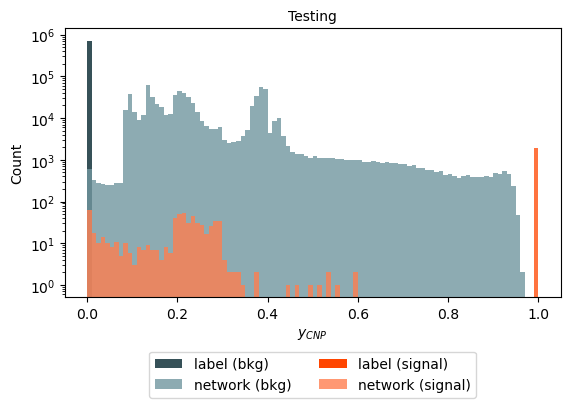

<Figure size 640x480 with 0 Axes>

In [ ]:


mode="HF"

filelist = utils.get_all_files(f"{resum_path}/simulation/out/{mode}/{version_hf}/tier3/neutron")

x_hf = np.empty([0,6])
sum_target_y_hf = np.empty([0,1])
mean_mu_cnp_hf = np.empty([0,1])
mean_sigma_cnp_hf = np.empty([0,1])
upper_lim_hf = np.empty([0,1])
rGe77_hf = np.empty([0,1])
totGe77_hf = np.empty([0,1])
hist_target_sig_hf = hist_target_bkg_hf = hist_pred_sig_hf = hist_pred_bkg_hf = np.zeros(100)
fout = open(f'{path_out}{f_out}_training.txt', "a")

# create a PdfPages object
pdf=PdfPages(f'{path_out}{f_out}_result_{mode}.pdf')

for i,file in enumerate(filelist):

    path_to_files = file[:-4]
    num_total_points = 0
    with open(file, "rbU") as f:
        num_total_points += int(np.floor(sum(1 for _ in f)))

    MAX_CONTEXT_POINTS_NEW = int(1/3 * (num_total_points-1))
    MAX_TARGET_POINTS_NEW = 2 * MAX_CONTEXT_POINTS_NEW

    dataset_config = data.DataGeneration(num_iterations=1, num_context_points=MAX_CONTEXT_POINTS_NEW, num_target_points=MAX_TARGET_POINTS_NEW, batch_size = 1, use_data_augmentation="None", path_to_files=path_to_files,x_size=x_size,y_size=y_size, mode = "config", ratio_testing=0.,names_x=names_x, name_y=name_y)
    data_config = dataset_config.get_data(0, CONTEXT_IS_SUBSET)
    
    # Get the predicted mean and variance at the target points for the testing set
    log_prob_config, mu_config, sigma_config = model(data_config.query, data_config.target_y)
    # Define the loss
    config_loss = -log_prob_config.mean()
    if max(mu_config[0].detach().numpy()) <= 1 and min(mu_config[0].detach().numpy()) >= 0:
            loss_bce_config = bce(mu_config,  data_config.target_y)
    else:
            loss_bce_config = -1.

    mu_config = mu_config[0].detach().numpy()
    
    target_y = data_config.target_y[0].detach().numpy()
    df = pd.read_csv(file, index_col=0)
    x_hf         = np.append(x_hf,[df[["fidelity","radius","thickness","npanels","theta","length"]].to_numpy()[0]],axis=0)
    #x         = np.append(x,[data_config.query[1][0][0][-5:].numpy()],axis=0)
    sum_target_y_tmp = np.array([np.sum(target_y)])
    sum_target_y_hf    = np.append(sum_target_y_hf, [sum_target_y_tmp], axis=0)
    mean_mu_tmp = np.array([np.mean(mu_config)])
    upper_lim_hf = np.append(upper_lim_hf,[np.array([np.percentile(mu_config,95.)])], axis=0)
    mean_mu_cnp_hf = np.append(mean_mu_cnp_hf, [mean_mu_tmp], axis=0)
    mean_sigma_tmp = np.array([np.mean(sigma_config[0].detach().numpy())])
    mean_sigma_cnp_hf = np.append(mean_sigma_cnp_hf, [mean_sigma_tmp], axis=0)
    rGe77_hf = np.append(rGe77_hf,[np.array([np.sum(pd.read_csv(file)["prod_rate_Ge77[nuc/(kg*yr)]"].to_numpy())])], axis=0)
    totGe77_hf = np.append(totGe77_hf,[np.array([np.sum(pd.read_csv(file)["total_nC_Ge77[cts]"].to_numpy())])], axis=0)

    hist_target_sig_hf, hist_target_bkg_hf, hist_pred_sig_hf, hist_pred_bkg_hf = plotting.sum_hist(mu_config, target_y, hist_target_sig_hf, hist_target_bkg_hf, hist_pred_sig_hf, hist_pred_bkg_hf)
    print("{}/{} {}, {}, radius: {} cm, test loss: {} (bce {})".format(i,len(filelist),datetime.datetime.now().strftime("%Y-%m-%d %H:%M:%S"), mode,x_hf[-1,1], config_loss, loss_bce_config))
    fout.write("{}, Iteration: {}, test loss: {} (bce {})\n".format(datetime.datetime.now().strftime("%Y-%m-%d %H:%M:%S"), i, config_loss, loss_bce_config))
   
    fig = plotting.plot_result_configwise(mu_config, target_y, f'{config_loss:.2f}', x_hf[-1][1:])
    pdf.savefig(fig)
    #plt.show()
    plt.clf()

    
fig1 = plotting.plot_result_summed(hist_target_sig_hf, hist_target_bkg_hf, hist_pred_sig_hf, hist_pred_bkg_hf)
pdf.savefig(fig1)
plt.show()
plt.clf()
pdf.close()

fout.close()

df= pd.read_csv(f'{path_out}{f_out}_Ge77rates.csv', index_col=0)
x = df[["Mode","Radius[cm]","Thickness[cm]","NPanels","Theta[deg]","Length[cm]","Ge-77[nevents]","Ge-77_CNP","Ge-77_CNP_err","rGe77[nuc/(kg*yr)]"]].to_numpy()
x_tmp = np.append(x_hf, sum_target_y_hf, axis=1)
x_tmp = np.append(x_tmp, mean_mu_cnp_hf, axis=1)
x_tmp = np.append(x_tmp, mean_sigma_cnp_hf, axis=1)
x_tmp = np.append(x_tmp, rGe77_hf, axis=1)
x = np.append(x, x_tmp, axis=0)
df = pd.DataFrame(x, columns=df.columns)

df=df.round(decimals=4)
df.to_csv(f'{path_out}{f_out}_Ge77rates.csv')
df.to_csv(f'{resum_path}/multi-fidelity-gaussian-process/in/Ge77_rates_CNP_{version_cnp}.csv')


In [17]:
import pickle as pkl

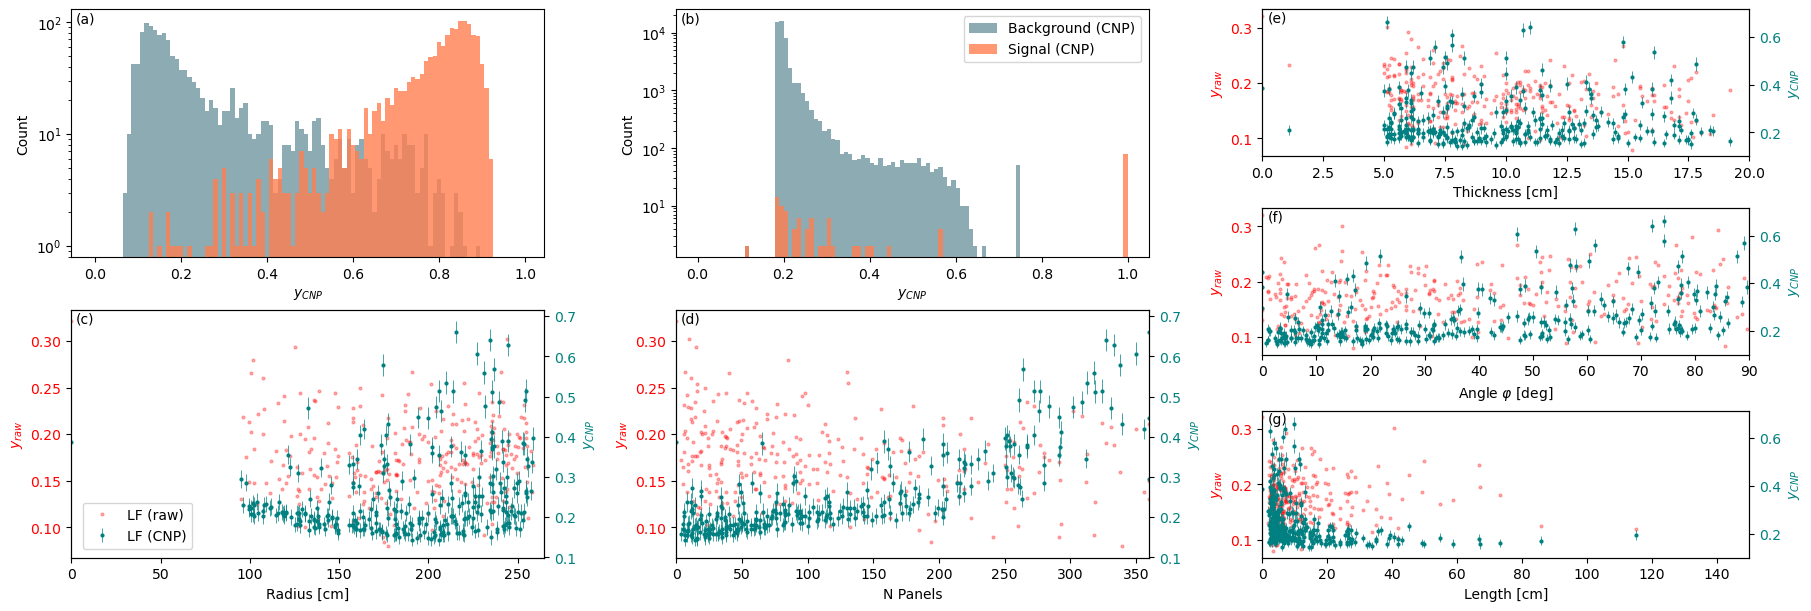

In [ ]:
color_sim_hf="black"
color_cnp_hf="black"
color_sim_lf="red"
color_cnp_lf="teal"

figx = pkl.load(  open(f'{resum_path}/out/{f_out}_distr.p',  'rb')  )

y1=[]
x2=[]
x1=[]
y2=[]
w1=[]
w2=[]
p = figx.axes[0].patches  # There are 10 patches
for i in range(int(len(p)/2)):
    x1.append(p[i].get_xy()[0])
    y1.append(p[i].get_height())
    w1.append(p[i].get_width())
    x2.append(p[i+int(len(p)/2)].get_xy()[0])
    y2.append(p[i+int(len(p)/2)].get_height())
    w2.append(p[i+int(len(p)/2)].get_width())
figx=[]
p=[]

xmin=[0,0,0,0,0]
xmax=[265,20,360,90,150]
indices = [0,2,1,3,4]
indices_l = ["(c)","(d)","(e)","(f)","(g)"]
xlabels=["Radius [cm]","Thickness [cm]","N Panels",r"Angle $\varphi$ [deg]","Length [cm]"]

fig = plt.figure(figsize=(18,6), layout = "constrained")
gs0=fig.add_gridspec(1,2, width_ratios = [2,1])

gs00 = gs0[0].subgridspec(2,2)
gs01 = gs0[1].subgridspec(3,1)
for l in range(2):
    for j in range(2):
        ax = fig.add_subplot(gs00[l,j])
        if l== 0 and j==0:
            ax.bar(x=x1,height=y1,width=w1, color=(113/255,150/255,159/255), alpha=0.8)
            ax.bar(x=x2,height=y2,width=w2,color='coral', alpha=0.8)
            ax.set_xlabel(r"$y_{CNP}$", fontsize=10)
            ax.set_ylabel(r'Count', fontsize=10)
            ax.set_yscale("log")
            #ax.set_ylim(0.1,1000000)
            ax.text(.01, .99, '(a)', ha='left', va='top', transform=ax.transAxes)
        if l == 0 and j==1:
            nbins = len(hist_target_sig2)
            range2 = [0.0, 1.0]
            bin_length = (range2[1]-range2[0])/nbins
            bins = np.arange(range2[0],range2[1]+bin_length, bin_length)
            centroids = (bins[1:] + bins[:-1]) / 2

            #ax.hist(centroids, weights = hist_target_bkg2, range=range2, bins=nbins, color=(3/255,37/255,46/255), alpha=0.8, label='Background (Label)')
            ax.hist(centroids, weights = hist_pred_bkg2, range=range2, bins=nbins, color=(113/255,150/255,159/255), alpha=0.8, label='Background (CNP)')
            #ax.hist(centroids, weights = hist_target_sig2, range=range2, bins=nbins, color='orangered', alpha=1.0, label='Signal (Label)')
            ax.hist(centroids, weights = hist_pred_sig2, range=range2, bins=nbins, color='coral', alpha=0.8, label='Signal (CNP)')
            ax.set_xlabel(r"$y_{CNP}$", fontsize=10)
            ax.set_ylabel(r'Count', fontsize=10)
            ax.set_yscale("log")
            #ax.set_ylim(0.1,1000000)
            ax.text(.01, .99, '(b)', ha='left', va='top', transform=ax.transAxes)
            ax.legend(loc=9, bbox_to_anchor=(0.795,1.), ncol=1,fontsize=10)

        if l == 1:
            i=j
            plt.plot(x_lf[:,indices[i]+1],rGe77_lf,"o",markersize=2, color=color_sim_lf, alpha=0.3, label="LF (raw)")
            #plt.plot(x_hf[:,indices[i]+1],totGe77_hf,">",markersize=4, color=color_sim_hf, label="HF (raw)")
            ax.set_xlim(xmin[indices[i]],xmax[indices[i]])#
            ax.set_xlabel(xlabels[indices[i]], fontsize=10)
            ax.set_ylabel(r'$y_{raw}$',color=color_sim_lf, fontsize=10)
            plt.tick_params(axis='y', labelcolor=color_sim_lf)
            handles = plt.gca().get_legend_handles_labels()[0]
            labels = plt.gca().get_legend_handles_labels()[1]

            ax = plt.twinx()
            plt.errorbar(x_lf[:,indices[i]+1], mean_mu_cnp_lf[:,0], yerr=mean_sigma_cnp_lf[:,0],fmt='o',markersize=2, elinewidth=0.5, color=color_cnp_lf, label="LF (CNP)")
            #plt.errorbar(x_hf[:,indices[i]+1], mean_mu_cnp_hf[:,0], yerr=mean_sigma_cnp_hf[:,0],fmt='s',markersize=4, color=color_cnp_hf, label="HF (CNP)")
            plt.tick_params(axis='y', labelcolor=color_cnp_lf)

            for t in range(len(plt.gca().get_legend_handles_labels()[1])):
                handles.append(plt.gca().get_legend_handles_labels()[0][t])
                labels.append(plt.gca().get_legend_handles_labels()[1][t])

            ax.set_ylabel(r'$y_{CNP}$',color=color_cnp_lf, fontsize=10)
            ax.text(.01, .99,indices_l[i], ha='left', va='top', transform=ax.transAxes)
            if j==0:
                plt.legend(handles,labels,loc=9, bbox_to_anchor=(0.14,0.25),ncol=1)

for j in range(3):
    ax = fig.add_subplot(gs01[j])
    i=j+2
    plt.plot(x_lf[:,indices[i]+1],rGe77_lf,'o',markersize=2, color=color_sim_lf,alpha=0.3, label="LF (raw)")
    #plt.plot(x_hf[:,indices[i]+1],totGe77_hf,'s',markersize=4, color=color_sim_hf, label="HF (raw)")
    ax.set_xlim(xmin[indices[i]],xmax[indices[i]])#
    ax.set_xlabel(xlabels[indices[i]], fontsize=10)
    ax.set_ylabel(r'$y_{raw}$',color=color_sim_lf, fontsize=10)
    
    plt.tick_params(axis='y', labelcolor=color_sim_lf)
    
    ax = plt.twinx()
    #plt.plot(x_lf[:,indices[i]+1], mean_mu_cnp_lf[:,0],'o',markersize=2, color=color_cnp_lf, label="LF (CNP)")
    plt.errorbar(x_lf[:,indices[i]+1], mean_mu_cnp_lf[:,0], yerr=mean_sigma_cnp_lf[:,0],fmt='o',markersize=2, elinewidth=0.5, color=color_cnp_lf, label="LF (CNP)")
    #plt.errorbar(x_hf[:,indices[i]+1], mean_mu_cnp_hf[:,0], yerr=mean_sigma_cnp_hf[:,0],fmt='>',markersize=4, color=color_cnp_hf, label="HF (CNP)")
    plt.tick_params(axis='y', labelcolor=color_cnp_lf)
    ax.set_ylabel(r'$y_{CNP}$',color=color_cnp_lf, fontsize=10)
    ax.text(.01, .99,indices_l[i], ha='left', va='top', transform=ax.transAxes)
fig.savefig(f'{path_out}{f_out}_result.png')

